# Final Analysis and Conclusions

## Objective

The objective of this notebook is to analyze and summarize the performance of all machine learning models developed for predicting drug combination synergy scores.

This notebook:
- Loads the saved model comparison results.
- Visualizes the performance of all models.
- Analyzes feature importance of the best-performing model.
- Evaluates prediction quality.
- Summarizes key findings and future improvements.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
import seaborn as sns

print(sns.__version__)

0.13.2


## Load Model Comparison Results

In [3]:
results_df = pd.read_csv("../results/model_comparison.csv")

results_df

,Model,RMSE,MAE,R2
0,Random Forest,10.437498,6.889754,0.305687
1,Extra Trees,10.561562,6.994630,0.289083
2,XGBoost,10.831528,7.150971,0.252275
3,CatBoost,11.138290,7.279685,0.209322
4,LightGBM,11.182242,7.281398,0.203070


## Best Performing Model

In [4]:
best_model = results_df.iloc[0]

print("Best Model Summary")
print("-" * 40)
print(best_model)

Best Model Summary
----------------------------------------
Model    Random Forest
RMSE         10.437498
MAE           6.889754
R2            0.305687
Name: 0, dtype: object


## RMSE Comparison

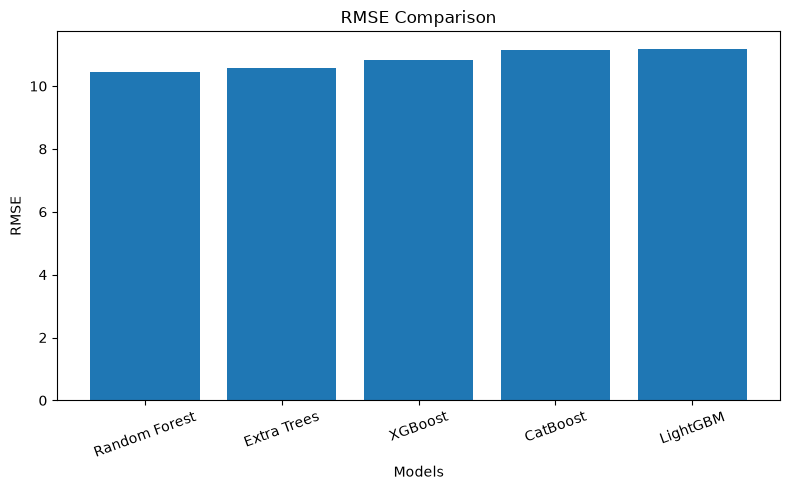

In [5]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xlabel("Models")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

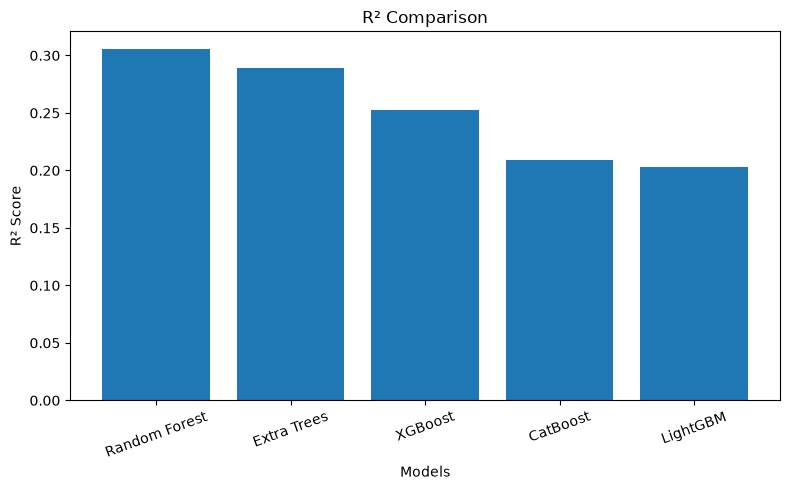

In [6]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R2"])

plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.xlabel("Models")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Feature Importance Analysis

In [7]:
feature_importance = pd.read_csv(
    "../results/random_forest_feature_importance.csv"
)

feature_importance.head(10)

,Feature,Importance
0,CONC1,0.042719
1,CONCINDEX1,0.039847
2,TPSA_2,0.032664
3,MolLogP_1,0.032103
4,FractionCSP3_1,0.026904
5,MolMR_1,0.026397
6,TPSA_1,0.025925
7,MolLogP_2,0.024329
8,CONC2,0.022192
9,FractionCSP3_2,0.020458


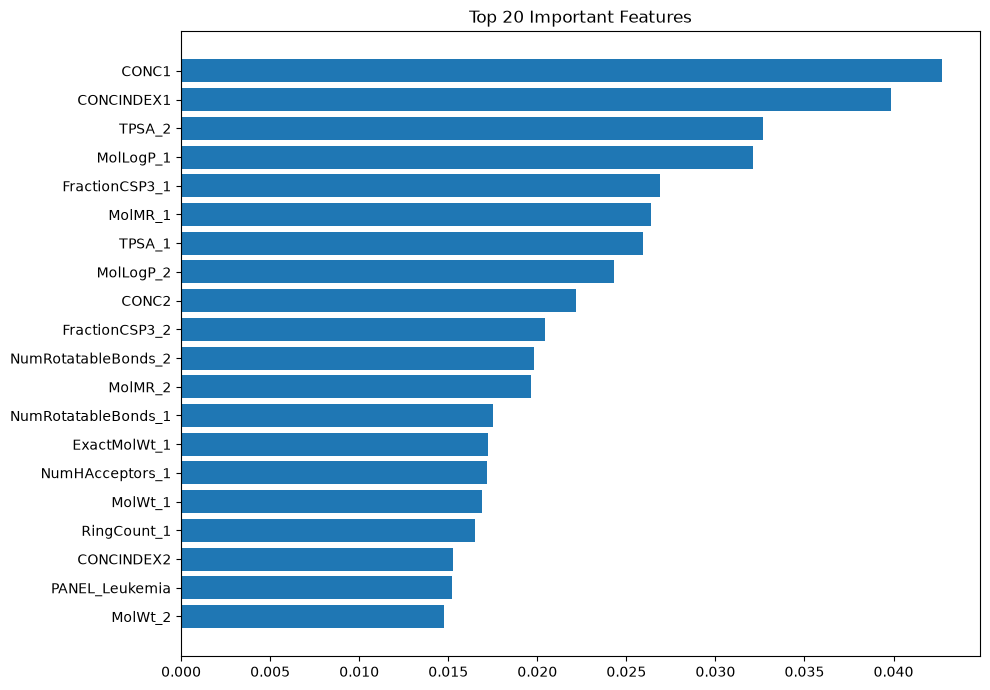

In [8]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# Conclusions

- Random Forest achieved the best overall performance among all evaluated models.

- Extra Trees produced comparable results but with slightly lower predictive performance.

- XGBoost, LightGBM, and CatBoost performed reasonably well but did not outperform Random Forest on this dataset.

- Molecular descriptors combined with drug combination information provide useful predictive features for drug response modeling.

- Feature importance analysis identified the most influential molecular descriptors contributing to prediction accuracy.

- The developed pipeline successfully demonstrates an end-to-end machine learning workflow for drug combination prediction.

# Future Work

- Perform hyperparameter tuning using GridSearchCV or Optuna.

- Evaluate deep learning models such as MLPs and Graph Neural Networks.

- Incorporate molecular fingerprints and graph-based molecular representations.

- Use cross-validation for more robust model evaluation.

- Improve model interpretability using SHAP values.

- Deploy the final model as a web application using Streamlit or Flask.

# Project Summary

This project developed a complete machine learning pipeline for predicting drug combination response using molecular descriptors.

The workflow included data preprocessing, feature engineering, baseline model development, comparison of five machine learning algorithms, feature importance analysis, and final performance evaluation.

Among all evaluated models, Random Forest achieved the best predictive performance and was selected as the final model.